Instead of raw daily_change,

My target will be next day pct change.

In [67]:
# Next day closing price
df_model['next_close'] = (
    df_model.groupby('ticker')['close'].shift(-1)
)

# Remove final row per ticker for which next_close does not exist)
df_model = df_model[
    df_model['next_close'].notna()
].copy()


# Next close change
df_model['next_close_change'] = df_model['next_close'] - df_model['close']


# Next close change PCT - This will be our target
df_model['next_close_change_pct'] = (
    (df_model['next_close'] - df_model['close']) / df_model['close']
) * 100


df_model

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,close_vs_open_pct,...,MACD,MACD_signal,MACD_hist,rolling_volatility,close_lag1,close_lag2,return_lag1,next_close,next_close_change,next_close_change_pct
0,2021-07-15,AA,35.27,35.9300,34.2350,34.54,8.679014e+06,34.9029,59127.0,-0.020697,...,-0.409851,-0.364569,-0.045282,0.038311,35.14,35.62,-0.013476,32.95,-1.59,-4.603358
1,2021-07-16,AA,35.35,35.7000,32.7323,32.95,1.478064e+07,33.4495,91473.0,-0.067893,...,-0.620150,-0.415686,-0.204464,0.019171,34.54,35.14,-0.017075,31.62,-1.33,-4.036419
2,2021-07-19,AA,31.99,32.4500,30.9950,31.62,1.240088e+07,31.6877,83015.0,-0.011566,...,-0.883943,-0.509337,-0.374606,0.015777,32.95,34.54,-0.046034,34.95,3.33,10.531309
3,2021-07-20,AA,31.55,35.2602,31.2600,34.95,1.578655e+07,34.1895,99391.0,0.107765,...,-0.814904,-0.570450,-0.244454,0.061817,31.62,32.95,-0.040364,37.09,2.14,6.123033
4,2021-07-21,AA,35.25,37.4100,35.2500,37.09,1.200015e+07,36.7297,74959.0,0.052199,...,-0.580815,-0.572523,-0.008292,0.067239,34.95,31.62,0.105313,37.23,0.14,0.377460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478377,2026-04-22,ZTS,118.95,119.9100,116.6000,117.52,3.514671e+06,117.4376,46220.0,-0.012022,...,-0.073311,-0.309622,0.236311,0.023783,118.18,122.72,-0.036995,116.06,-1.46,-1.242342
478378,2026-04-23,ZTS,117.19,117.5999,114.9500,116.06,4.532932e+06,116.0779,57313.0,-0.009642,...,-0.336494,-0.314996,-0.021497,0.023624,117.52,118.18,-0.005585,116.87,0.81,0.697915
478379,2026-04-24,ZTS,116.01,117.0500,115.4100,116.87,4.185102e+06,116.4944,52997.0,0.007413,...,-0.474241,-0.346845,-0.127396,0.017329,116.06,117.52,-0.012423,117.87,1.00,0.855652
478380,2026-04-27,ZTS,116.62,119.6800,116.6000,117.87,3.160355e+06,118.2275,43149.0,0.010719,...,-0.496987,-0.376874,-0.120113,0.018470,116.87,116.06,0.006979,116.65,-1.22,-1.035039


In [107]:
test = 234
test

234

In [ ]:
%%time

# Import libraries
import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit,
    GridSearchCV,
    cross_val_score,
    KFold
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)


# Load dataset
df_model = pd.read_csv(
    'transformed_daily_data/daily_data_5y_30k_features1.csv'
)

# Prepare dataset

# Ensure datetime formatting
df_model['timestamp'] = pd.to_datetime(df_model['timestamp'])

# Sort dataset
df_model = df_model.sort_values(
    ['ticker', 'timestamp']
).copy()


# Next day closing price
df_model['next_close'] = (
    df_model.groupby('ticker')['close'].shift(-1)
)

# Remove final row per ticker for which next_close does not exist
df_model = df_model[
    df_model['next_close'].notna()
].copy()


# Next close change
df_model['next_close_change'] = df_model['next_close'] - df_model['close']


# Next close change PCT - This will be the target
df_model['next_close_change_pct'] = (
    (df_model['next_close'] - df_model['close']) / df_model['close']
) * 100



# Remove final row per ticker for which next_close does not exist)
df_model = df_model[
    df_model['next_close'].notna()
].copy()



# Train/test split

# Train on 2021-2024 data
train_df = df_model[
    (df_model['timestamp'] >= '2021-01-01') &
    (df_model['timestamp'] < '2025-01-01')
].copy()

# Test on 2025 data
test_df = df_model[
    (df_model['timestamp'] >= '2025-01-01') &
    (df_model['timestamp'] < '2026-01-01')
].copy()


# Select features - exclude index, target, and a couple columns that will leak too much
exclude_cols = [
    'timestamp',
    'ticker',
    'next_close',
    'next_close_change',
    'next_close_change_pct'
]

feature_cols = [
    col for col in df_model.columns
    if col not in exclude_cols
]


X_train = train_df[feature_cols]
y_train = train_df['next_close_change_pct']

X_test = test_df[feature_cols]
y_test = test_df['next_close_change_pct']


# Define model
model = RandomForestRegressor(random_state=42)

# Add GridSearch (not doing it in this initial notebook, just saving my place)


# Train model
model.fit(X_train, y_train)


# Get predictinos
y_test_pred = model.predict(X_test)


# Define evaluation metrics
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
medae = median_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

# Print evaluation metrics
print("\n===== REGRESSION METRICS =====")

print(f"MAE:    {mae:.4f}")
print(f"MSE:    {mse:.4f}")
print(f"RMSE:   {rmse:.4f}")
print(f"MedAE:  {medae:.4f}")
print(f"R²:     {r2:.4f}")

In [47]:
results_df = test_df.copy()

# Add predictions
results_df['pred_next_close_change_pct'] = (y_test_pred).round(2)

# Impute error
results_df['pred_error'] = results_df['pred_next_close_change_pct'] - results_df['next_close_change_pct']

# Absolute error
results_df['abs_pred_error'] = results_df['pred_error'].abs()

# Directionally correct
results_df['directionally_correct'] = (
    np.sign(results_df['next_close_change_pct']) ==
    np.sign(results_df['pred_next_close_change_pct'])
).astype(int)

results_df

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,close_vs_open_pct,...,close_lag1,close_lag2,return_lag1,next_close,next_close_change,next_close_change_pct,pred_next_close_change_pct,pred_error,abs_pred_error,directionally_correct
872,2025-01-02,AA,38.165,39.0400,37.9000,37.99,2703886.0,38.3283,33119.0,-0.004585,...,37.78,37.15,0.016958,35.71,-2.28,-6.001579,-6.03,-2.842064e-02,2.842064e-02,1
873,2025-01-03,AA,37.950,37.9500,35.3752,35.71,7491799.0,35.9337,63814.0,-0.059025,...,37.99,37.78,0.005558,36.49,0.78,2.184262,2.16,-2.426211e-02,2.426211e-02,1
874,2025-01-06,AA,36.000,37.0750,35.9200,36.49,5983917.0,36.4794,58230.0,0.013611,...,35.71,37.99,-0.060016,36.24,-0.25,-0.685119,-0.69,-4.880789e-03,4.880789e-03,1
875,2025-01-07,AA,36.890,37.3000,35.7550,36.24,3381466.0,36.2093,39434.0,-0.017620,...,36.49,35.71,0.021843,36.00,-0.24,-0.662252,-0.66,2.251656e-03,2.251656e-03,1
876,2025-01-08,AA,35.780,36.0300,34.7500,36.00,3775303.0,35.5672,41012.0,0.006149,...,36.24,36.49,-0.006851,35.91,-0.09,-0.250000,-0.25,9.436896e-15,9.436896e-15,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478297,2025-12-24,ZTS,123.100,125.6899,123.0600,125.49,2369020.0,125.1484,29115.0,0.019415,...,123.54,123.78,-0.001939,126.23,0.74,0.589688,0.59,3.115786e-04,3.115786e-04,1
478298,2025-12-26,ZTS,125.160,126.3200,124.8000,126.23,3226934.0,125.8979,45295.0,0.008549,...,125.49,123.54,0.015784,125.98,-0.25,-0.198051,-0.20,-1.948824e-03,1.948824e-03,1
478299,2025-12-29,ZTS,126.160,126.8500,125.5607,125.98,4465924.0,126.0785,51439.0,-0.001427,...,126.23,125.49,0.005897,126.41,0.43,0.341324,0.34,-1.324020e-03,1.324020e-03,1
478300,2025-12-30,ZTS,125.550,127.6000,125.4500,126.41,3230541.0,126.5667,45221.0,0.006850,...,125.98,126.23,-0.001981,125.82,-0.59,-0.466735,-0.47,-3.264773e-03,3.264773e-03,1


In [48]:
results_df['directionally_correct'].value_counts()

directionally_correct
1    99209
0       41
Name: count, dtype: int64

In [49]:
# Save
results_df.to_csv('models_daily_results/Round_1_RFR.csv', index=False)

In [50]:
daily_prediction_summary = (
    results_df
    .groupby('timestamp')
    .agg(
        stocks_predicted=('ticker', 'count'),

        actual_next_close_pct_change_mean=('next_close_change_pct', 'mean'),
        predicted_next_close_pct_change_mean=('pred_next_close_change_pct', 'mean'),

        pred_error_mean=('pred_error', 'mean'),
        pred_error_median=('pred_error', 'median'),

        abs_pred_error_mean=('abs_pred_error', 'mean'),
        abs_pred_error_median=('abs_pred_error', 'median'),

        pred_error_std=('pred_error', 'std'),

        max_overprediction=('pred_error', 'max'),
        max_underprediction=('pred_error', 'min'),

        directional_accuracy_pct=('directionally_correct', 'mean')
    )
    .reset_index()
)

# Convert to percentage
daily_prediction_summary['directional_accuracy_pct'] *= 100

daily_prediction_summary

,timestamp,stocks_predicted,actual_next_close_pct_change_mean,predicted_next_close_pct_change_mean,pred_error_mean,pred_error_median,abs_pred_error_mean,abs_pred_error_median,pred_error_std,max_overprediction,max_underprediction,directional_accuracy_pct
0,2025-01-02,397,1.421792,1.423526,0.001735,-0.001039,0.020268,0.004263,0.090912,1.263774,-0.883231,100.000000
1,2025-01-03,397,1.280758,0.786096,-0.494663,0.000197,0.523939,0.004199,10.069361,1.891333,-200.608889,100.000000
2,2025-01-06,397,-0.608645,-0.596071,0.012574,-0.000320,0.022377,0.003939,0.250494,4.964862,-0.270794,100.000000
3,2025-01-07,397,-0.444311,-0.444005,0.000306,-0.000171,0.009623,0.003457,0.036105,0.249205,-0.568874,100.000000
4,2025-01-08,397,-1.548944,-1.549647,-0.000703,-0.000435,0.012799,0.005094,0.037877,0.369363,-0.338976,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
245,2025-12-24,397,-0.095907,-0.094987,0.000919,0.000114,0.005010,0.002955,0.011880,0.135503,-0.051627,99.748111
246,2025-12-26,397,-0.484840,-0.486524,-0.001684,0.000000,0.008376,0.003274,0.042272,0.212222,-0.758750,100.000000
247,2025-12-29,397,-0.153850,-0.153552,0.000298,0.000260,0.007801,0.003494,0.038090,0.528619,-0.501840,100.000000
248,2025-12-30,397,-0.857997,-0.861763,-0.003766,-0.000152,0.009381,0.003488,0.070454,0.164856,-1.372730,100.000000


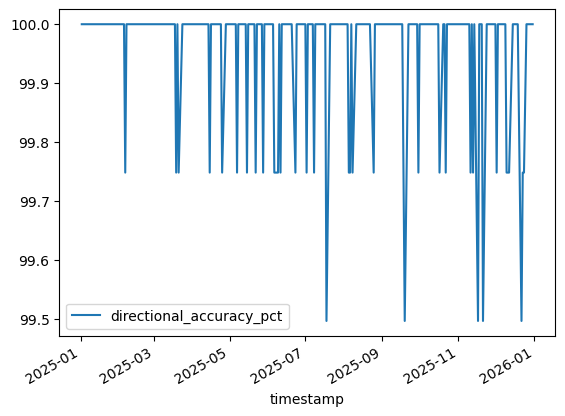

In [51]:
daily_prediction_summary.set_index('timestamp')[['directional_accuracy_pct']].plot()
plt.show()

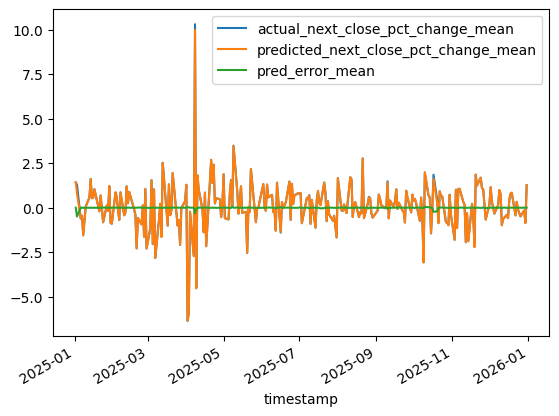

In [52]:
daily_prediction_summary.set_index('timestamp')[['actual_next_close_pct_change_mean', 'predicted_next_close_pct_change_mean', 'pred_error_mean']].plot()
plt.show()

In [55]:
daily_prediction_summary.nsmallest(10, 'directional_accuracy_pct')

,timestamp,stocks_predicted,actual_next_close_pct_change_mean,predicted_next_close_pct_change_mean,pred_error_mean,pred_error_median,abs_pred_error_mean,abs_pred_error_median,pred_error_std,max_overprediction,max_underprediction,directional_accuracy_pct
134,2025-07-18,397,0.163681,0.130504,-0.033177,0.000131,0.047783,0.003259,0.611642,1.282743,-11.950157,99.496222
178,2025-09-19,397,0.280833,0.290176,0.009343,0.001013,0.017766,0.003940,0.085157,1.187464,-0.442618,99.496222
219,2025-11-17,397,0.220547,0.220705,0.000159,-0.000300,0.009890,0.004231,0.032423,0.540272,-0.174126,99.496222
223,2025-11-21,397,1.239224,1.247935,0.008711,0.000253,0.025667,0.004991,0.131796,2.359638,-0.629377,99.496222
243,2025-12-22,397,-0.426112,-0.426499,-0.000387,-0.000057,0.006510,0.003264,0.018698,0.097477,-0.286398,99.496222
23,2025-02-06,397,-0.693852,-0.681763,0.012089,0.000000,0.030256,0.003626,0.272418,5.196347,-0.993765,99.748111
51,2025-03-19,397,-0.418245,-0.418992,-0.000748,-0.000100,0.006811,0.003145,0.024953,0.131573,-0.430285,99.748111
53,2025-03-21,397,1.950308,1.956423,0.006115,0.001997,0.025173,0.005548,0.102612,0.496423,-1.602924,99.748111
70,2025-04-15,397,-1.377353,-1.377783,-0.000430,0.000465,0.010171,0.004742,0.026355,0.170981,-0.361966,99.748111
77,2025-04-25,397,0.538359,0.530252,-0.008107,0.000391,0.018731,0.003537,0.195839,0.252456,-3.857674,99.748111


In [56]:
daily_prediction_summary.nlargest(10, 'abs_pred_error_mean')

,timestamp,stocks_predicted,actual_next_close_pct_change_mean,predicted_next_close_pct_change_mean,pred_error_mean,pred_error_median,abs_pred_error_mean,abs_pred_error_median,pred_error_std,max_overprediction,max_underprediction,directional_accuracy_pct
1,2025-01-03,397,1.280758,0.786096,-0.494663,0.000197,0.523939,0.004199,10.069361,1.891333,-200.608889,100.000000
65,2025-04-08,397,10.308052,9.986599,-0.321453,-0.128503,0.360195,0.142101,0.659139,2.979271,-5.295400,100.000000
198,2025-10-17,397,1.855796,1.625340,-0.230456,0.000164,0.259664,0.004783,4.725255,3.503017,-94.075167,99.748111
199,2025-10-20,397,0.425636,0.224458,-0.201177,0.000405,0.216337,0.003885,3.987290,0.623511,-79.438503,100.000000
193,2025-10-10,397,1.947979,2.001637,0.053659,-0.005498,0.102807,0.007993,1.205795,23.657463,-0.558231,100.000000
170,2025-09-09,397,0.012196,0.040781,0.028585,0.000042,0.102304,0.004330,1.248670,21.697318,-12.038822,100.000000
61,2025-04-02,397,-6.358696,-6.340630,0.018066,-0.001919,0.099261,0.026675,0.274922,3.262973,-1.147443,100.000000
86,2025-05-08,397,0.077109,0.135718,0.058609,-0.000061,0.088339,0.004212,0.943947,16.884953,-3.206923,100.000000
183,2025-09-26,397,0.574603,0.583325,0.008722,0.000661,0.086360,0.004005,1.007807,14.600351,-13.639565,100.000000
62,2025-04-03,397,-5.948873,-5.920353,0.028520,0.009639,0.077711,0.028538,0.181332,1.406118,-2.027754,100.000000


# Comparing with the raw target

In [57]:
# Load raw target dataframe, calculate percentages
raw_target_df = pd.read_csv('models_daily_results/daily_raw_target_preds_RFR.csv')
raw_target_df = raw_target_df[['timestamp', 'ticker', 'next_close', 'pred_next_close', 'pred_error', 'abs_pred_error']]
#raw_preds_df.rename(columns={'pred_error': 'Raw Target Pred Error'}, inplace=True)
#raw_preds_df.rename(columns={'abs_pred_error': 'ABS Raw Target Pred Error'}, inplace=True)
raw_target_df['timestamp'] = pd.to_datetime(raw_target_df['timestamp'])

raw_target_df['pred_error_pct'] = (
    (raw_target_df['pred_error'] / raw_target_df['next_close']) * 100
)

raw_target_df['abs_pred_error_pct'] = (
    (raw_target_df['abs_pred_error'] / raw_target_df['next_close']) * 100
)


# Pct target df
pct_target_df = results_df[['ticker', 'timestamp', 'next_close', 'pred_next_close_change_pct', 'pred_error', 'abs_pred_error']]




# Make clean copies
raw_target_merge = raw_target_df[[
    'ticker', 'timestamp',
    'pred_error_pct', 'abs_pred_error_pct'
]].copy()

pct_target_merge = pct_target_df[[
    'ticker', 'timestamp', 'next_close',
    'pred_error', 'abs_pred_error'
]].copy()

# Ensure matching datetime type
raw_target_merge['timestamp'] = pd.to_datetime(raw_target_merge['timestamp'])
pct_target_merge['timestamp'] = pd.to_datetime(pct_target_merge['timestamp'])

# Rename columns before merge
raw_target_merge = raw_target_merge.rename(columns={
    'pred_error_pct': 'raw_target_pct_error',
    'abs_pred_error_pct': 'raw_target_pct_error_abs'
})

pct_target_merge = pct_target_merge.rename(columns={
    'pred_error': 'pct_target_pct_error',
    'abs_pred_error': 'pct_target_pct_error_abs'
})

# Merge on ticker + timestamp
comparison_df = pct_target_merge.merge(
    raw_target_merge,
    on=['ticker', 'timestamp'],
    how='left'
)

# Improvement
comparison_df['raw_to_pct_target_improvement'] = comparison_df['raw_target_pct_error_abs'] - comparison_df['pct_target_pct_error_abs']

comparison_df

,ticker,timestamp,next_close,pct_target_pct_error,pct_target_pct_error_abs,raw_target_pct_error,raw_target_pct_error_abs,raw_to_pct_target_improvement
0,AA,2025-01-02,35.71,-2.842064e-02,2.842064e-02,7.308877,7.308877,7.280456e+00
1,AA,2025-01-03,36.49,-2.426211e-02,2.426211e-02,-1.315429,1.315429,1.291167e+00
2,AA,2025-01-06,36.24,-4.880789e-03,4.880789e-03,0.055188,0.055188,5.030685e-02
3,AA,2025-01-07,36.00,2.251656e-03,2.251656e-03,0.361111,0.361111,3.588595e-01
4,AA,2025-01-08,35.91,9.436896e-15,9.436896e-15,0.000000,0.000000,-9.436896e-15
...,...,...,...,...,...,...,...,...
99245,ZTS,2025-12-24,126.23,3.115786e-04,3.115786e-04,-0.507011,0.507011,5.066994e-01
99246,ZTS,2025-12-26,125.98,-1.948824e-03,1.948824e-03,-0.095253,0.095253,9.330439e-02
99247,ZTS,2025-12-29,126.41,-1.324020e-03,1.324020e-03,-0.395538,0.395538,3.942143e-01
99248,ZTS,2025-12-30,125.82,-3.264773e-03,3.264773e-03,0.532507,0.532507,5.292420e-01


In [58]:
comparison_df['raw_to_pct_target_improvement'].mean()

np.float64(2.170581366887068)

In [59]:
comparison_df['raw_to_pct_target_improvement'].median()

np.float64(1.2638934336596979)

In [60]:
comparison_df['raw_target_pct_error_abs'].mean()

np.float64(2.1981255598558005)

In [61]:
comparison_df['raw_target_pct_error_abs'].median()

np.float64(1.2702532189204612)

In [62]:
comparison_df['pct_target_pct_error_abs'].mean()

np.float64(0.027544192968732464)

In [63]:
comparison_df['pct_target_pct_error_abs'].median()

np.float64(0.004434425452210636)

# Comparing with simple directionality

In [64]:
classif_df = pd.read_csv('classification_daily_results/rf_classification.csv')
classif_df

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,close_vs_open_pct,...,rolling_volatility,close_lag1,close_lag2,return_lag1,next_close,target,Prediction,Prediction Correct,Prediction Probability,Prediction Confidence
0,2025-01-02,AA,38.165,39.0400,37.9000,37.99,2703886.0,38.3283,33119.0,-0.004585,...,0.014294,37.78,37.15,0.016958,35.71,0,1,0,0.53,0.53
1,2025-01-03,AA,37.950,37.9500,35.3752,35.71,7491799.0,35.9337,63814.0,-0.059025,...,0.029454,37.99,37.78,0.005558,36.49,1,1,1,0.57,0.57
2,2025-01-06,AA,36.000,37.0750,35.9200,36.49,5983917.0,36.4794,58230.0,0.013611,...,0.033236,35.71,37.99,-0.060016,36.24,0,0,1,0.49,0.51
3,2025-01-07,AA,36.890,37.3000,35.7550,36.24,3381466.0,36.2093,39434.0,-0.017620,...,0.032951,36.49,35.71,0.021843,36.00,0,1,0,0.55,0.55
4,2025-01-08,AA,35.780,36.0300,34.7500,36.00,3775303.0,35.5672,41012.0,0.006149,...,0.030724,36.24,36.49,-0.006851,35.91,0,1,0,0.53,0.53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99245,2025-12-24,ZTS,123.100,125.6899,123.0600,125.49,2369020.0,125.1484,29115.0,0.019415,...,0.008772,123.54,123.78,-0.001939,126.23,1,0,0,0.41,0.59
99246,2025-12-26,ZTS,125.160,126.3200,124.8000,126.23,3226934.0,125.8979,45295.0,0.008549,...,0.008752,125.49,123.54,0.015784,125.98,0,0,1,0.46,0.54
99247,2025-12-29,ZTS,126.160,126.8500,125.5607,125.98,4465924.0,126.0785,51439.0,-0.001427,...,0.008154,126.23,125.49,0.005897,126.41,1,1,1,0.66,0.66
99248,2025-12-30,ZTS,125.550,127.6000,125.4500,126.41,3230541.0,126.5667,45221.0,0.006850,...,0.007307,125.98,126.23,-0.001981,125.82,0,0,1,0.38,0.62


In [65]:
classif_df['Prediction Correct'].value_counts()

Prediction Correct
1    49805
0    49445
Name: count, dtype: int64

In [66]:
results_df['directionally_correct'].value_counts()

directionally_correct
1    99209
0       41
Name: count, dtype: int64

In [67]:
(classif_df['Prediction Correct'] == 1).mean() * 100

np.float64(50.18136020151134)

In [68]:
(results_df['directionally_correct'] == 1).mean() * 100

np.float64(99.95869017632242)